# Certified support-reduction variants A, B, and C

This notebook implements and benchmarks the three reductions specified in
`certified_polynomial_support_reduction_variants.tex` on the saved
100-dimensional Poisson PINN.  The network is loaded from its checkpoint and
is never retrained.

The two approximation choices are fixed across all reduction runs:

- function values use the certified affine approximation of $\tanh$;
- $\tanh'$ uses the certified endpoint-midpoint quadratic whenever the
  preactivation interval crosses zero and the affine approximation is flat.

Support selection and enclosure of discarded support are separate choices.
All main runs use coefficient-norm Top-$K$ support selection.  Variant A
replaces discarded terms by a symmetric coefficient-sum box.  Variant B uses
the exact $[0,1]$ range of componentwise-even monomials and adds the resulting
midpoint correction.  Variant C starts from B, retains a budget of correlated
coefficient-space generators as fresh approximation-noise symbols, and boxes
only the remaining directions.  The compact pointwise remainder tensor used
internally represents the axis-aligned generators of the final box without
allocating thousands of explicit zero-heavy coefficient tensors.

In [1]:
from math import sqrt
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from intervalnets import (
    IntervalTensor,
    PZIntegrationCell,
    enable_interval_eval,
    integrate_pz_onejet_squared,
    integrate_pz_value_squared,
    load_tanh_mlp_checkpoint,
)

torch.set_num_threads(1)
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 40)
torch.set_default_dtype(torch.float64)
enable_interval_eval()

repo_root = Path.cwd()
while not (repo_root / "notebooks" / "checkpoints").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
checkpoint = repo_root / "notebooks" / "checkpoints" / "pinn_100d_poisson.pt"
domain_volume = 0.2 ** 100
normalization = sqrt(domain_volume)

## Benchmark and diagnostic helpers

Widths below refer to the final norm interval, not the squared-norm interval.
The normalized width divides by $|\Omega|^{1/2}$, making the extremely small
100-dimensional volume invisible in the scale of the comparison.

In [2]:
def norm_interval(squared):
    return sqrt(max(0.0, float(squared.lower))), sqrt(max(0.0, float(squared.upper)))


def norm_metrics(squared, prefix):
    lower, upper = norm_interval(squared)
    width = upper - lower
    scale = max(abs(lower), abs(upper))
    return {
        f"{prefix}_lower": lower,
        f"{prefix}_upper": upper,
        f"{prefix}_width": width,
        f"{prefix}_normalized_lower": lower / normalization,
        f"{prefix}_normalized_upper": upper / normalization,
        f"{prefix}_normalized_width": width / normalization,
        f"{prefix}_relative_width": width / scale if scale else 0.0,
    }


def jacobian_metrics(enclosure):
    lower = torch.as_tensor(enclosure.lower)
    upper = torch.as_tensor(enclosure.upper)
    widths = upper - lower
    scales = torch.maximum(lower.abs(), upper.abs())
    relative = torch.where(scales > 0, widths / scales, 0.0)
    return {
        "J_mean_width": float(widths.mean()),
        "J_max_width": float(widths.max()),
        "J_mean_relative_width": float(relative.mean()),
    }


def benchmark_pz(model, box, label, **kwargs):
    cell = PZIntegrationCell.from_affine_box(box)
    start = perf_counter()
    traced = model.eval_pz_onejet(
        cell.domain,
        reduction_strategy="topk",
        derivative_enclosure="quadratic_flat",
        derivative_flatness_threshold=1.0,
        quadratic_compression_guard=False,
        return_trace=True,
        **kwargs,
    )
    forward_s = perf_counter() - start

    start = perf_counter()
    l2_pz = integrate_pz_value_squared(traced.final.Y, cell, output="pz")
    l2_squared = l2_pz.interval_enclosure()
    l2_s = perf_counter() - start

    start = perf_counter()
    w12_pz = integrate_pz_onejet_squared(traced.final, cell, output="pz")
    w12_squared = w12_pz.interval_enclosure()
    w12_s = perf_counter() - start

    row = {
        "method": label,
        **kwargs,
        "forward_s": forward_s,
        "L2_integration_s": l2_s,
        "W12_integration_s": w12_s,
        "total_s": forward_s + l2_s + w12_s,
        "J_terms": len(traced.final.J.terms),
        "J_degree": max(map(sum, traced.final.J.terms), default=0),
        "J_noise_symbols": traced.final.J.num_noise,
        "L2_integrated_terms": len(l2_pz.terms),
        "W12_integrated_terms": len(w12_pz.terms),
        **jacobian_metrics(traced.final.J.interval_enclosure()),
        **norm_metrics(l2_squared, "L2"),
        **norm_metrics(w12_squared, "W12"),
    }
    return row, traced.records


def benchmark_interval(model, box):
    start = perf_counter()
    l2 = model.lpnorm(box, p=2.0, method="interval")
    w12 = model.sobolev_norm(box, p=2.0, order=1, method="interval")
    elapsed = perf_counter() - start
    jacobian = model.eval_jacobian(box)
    def direct_metrics(bounds, prefix):
        lower, upper = float(bounds.lower), float(bounds.upper)
        width = upper - lower
        scale = max(abs(lower), abs(upper))
        return {
            f"{prefix}_lower": lower,
            f"{prefix}_upper": upper,
            f"{prefix}_width": width,
            f"{prefix}_normalized_lower": lower / normalization,
            f"{prefix}_normalized_upper": upper / normalization,
            f"{prefix}_normalized_width": width / normalization,
            f"{prefix}_relative_width": width / scale if scale else 0.0,
        }
    return {
        "method": "interval",
        "total_s": elapsed,
        **jacobian_metrics(jacobian),
        **direct_metrics(l2, "L2"),
        **direct_metrics(w12, "W12"),
    }


def activation_rows(method, trace):
    rows = []
    activations = [record for record in trace if record.layer_type == "Tanh"]
    for layer, record in enumerate(activations, start=1):
        summary = record.summary
        lower = summary["preactivation_lower"]
        upper = summary["preactivation_upper"]
        d_lo = 1.0 - torch.tanh(lower) ** 2
        d_hi = 1.0 - torch.tanh(upper) ** 2
        d_max = torch.where((lower <= 0) & (upper >= 0), torch.ones_like(lower), torch.maximum(d_lo, d_hi))
        interval_radius = 0.5 * (d_max - torch.minimum(d_lo, d_hi))
        for neuron in range(lower.numel()):
            rows.append({
                "method": method,
                "layer": layer,
                "neuron": neuron,
                "preactivation_lower": float(lower[neuron]),
                "preactivation_upper": float(upper[neuron]),
                "preactivation_width": float(upper[neuron] - lower[neuron]),
                "crosses_zero": bool(lower[neuron] <= 0 <= upper[neuron]),
                "relative_affine_slope": float(summary["tanh_prime_relative_slopes"][neuron]),
                "tanh_affine_rho": float(summary["tanh_approximation_radii"][neuron]),
                "tanh_prime_interval_radius": float(interval_radius[neuron]),
                "tanh_prime_affine_rho": float(summary["tanh_prime_affine_radii"][neuron]),
                "tanh_prime_selected_rho": float(summary["tanh_prime_approximation_radii"][neuron]),
                "quadratic_core_box_radius": float(summary["tanh_prime_polynomial_reduction_radii"][neuron]),
                "approximation_degree": int(summary["tanh_prime_approximation_degrees"][neuron]),
                "propagated_J_remainder_mean": summary["J"]["remainder_mean_radius"],
                "J_terms_after_activation": summary["J"]["term_count"],
                "J_degree_after_activation": summary["J"]["max_degree"],
                "J_noise_after_activation": summary["J"]["num_noise"],
                "activation_runtime_s": record.elapsed_s,
            })
    return rows

## Structural and small-network regression checks

These checks complement the unit tests.  They verify the expected ordering
for a discarded square and test sampled Jacobians against each certified
enclosure on a tractable network where an unreduced quadratic reference is
still feasible.

In [3]:
from intervalnets.pytorch import PZReductionConfig, _CertifiedTermReducer


def square_reduction(variant, generator_budget=0):
    center = torch.zeros(2)
    reducer = _CertifiedTermReducer(
        PZReductionConfig(
            strategy="topk", max_terms=1,
            reduction_variant=variant, generator_budget=generator_budget,
        ), tuple(center.shape), center,
    )
    reducer.offer((1,), torch.tensor([10.0, 0.0]))
    reducer.offer((2,), torch.tensor([2.0, -4.0]))
    return reducer.finish(center, num_noise=1, noise_kinds=("domain",))


structural = []
for variant, budget in [("A", 0), ("B", 0), ("C", 0), ("C", 1)]:
    reduced, radius = square_reduction(variant, budget)
    structural.append({
        "variant": variant, "generator_budget": budget,
        "center": reduced.center.tolist(), "box_radius": radius.tolist(),
        "noise_symbols": reduced.num_noise, "terms": len(reduced.terms),
    })
structural_table = pd.DataFrame(structural)
assert np.allclose(structural_table.loc[1, "box_radius"], [1.0, 2.0])
assert np.allclose(structural_table.loc[2, "box_radius"], [1.0, 2.0])
display(structural_table)

  variant  generator_budget       center  \
0       A                 0   [0.0, 0.0]   
1       B                 0  [1.0, -2.0]   
2       C                 0  [1.0, -2.0]   
3       C                 1  [1.0, -2.0]   

                                 box_radius  noise_symbols  terms  
0   [2.0000000000000004, 4.000000000000001]              1      1  
1  [1.0000000000000002, 2.0000000000000004]              1      1  
2  [1.0000000000000002, 2.0000000000000004]              1      1  
3                                [0.0, 0.0]              2      2  

In [4]:
torch.manual_seed(20260802)
small_model = torch.nn.Sequential(
    torch.nn.Linear(6, 8), torch.nn.Tanh(),
    torch.nn.Linear(8, 8), torch.nn.Tanh(),
    torch.nn.Linear(8, 1),
).double()
small_box = IntervalTensor.from_bounds([-0.3] * 6, [0.3] * 6)
small_cell = PZIntegrationCell.from_affine_box(small_box)
small_configs = [
    ("unreduced", dict(reduce=False)),
    ("A", dict(max_terms=24, reduction_variant="A")),
    ("B", dict(max_terms=24, reduction_variant="B")),
    ("C-0", dict(max_terms=24, reduction_variant="C", generator_budget=0)),
    ("C-8", dict(max_terms=24, reduction_variant="C", generator_budget=8)),
]
small_rows = []
for label, kwargs in small_configs:
    traced = small_model.eval_pz_onejet(
        small_cell.domain,
        reduction_strategy="topk",
        derivative_enclosure="quadratic_flat",
        derivative_flatness_threshold=1.0,
        quadratic_compression_guard=False,
        return_trace=True,
        **kwargs,
    )
    enclosure = traced.final.J.interval_enclosure()
    violations = 0
    for _ in range(64):
        point = torch.empty(6).uniform_(-0.3, 0.3).requires_grad_(True)
        gradient = torch.autograd.grad(small_model(point).sum(), point)[0]
        lo = torch.as_tensor(enclosure.lower)[0]
        hi = torch.as_tensor(enclosure.upper)[0]
        violations += int(torch.any((gradient < lo) | (gradient > hi)))
    small_rows.append({
        "method": label, "sample_violations": violations,
        "J_terms": len(traced.final.J.terms), "noise": traced.final.J.num_noise,
        **jacobian_metrics(enclosure),
    })
small_reference_table = pd.DataFrame(small_rows).set_index("method")
assert small_reference_table["sample_violations"].sum() == 0
display(small_reference_table)

           sample_violations  J_terms  noise  J_mean_width  J_max_width  \
method                                                                    
unreduced                  0     1895     28      0.062576     0.087104   
A                          0       30     28      0.073462     0.096885   
B                          0       30     28      0.068265     0.091551   
C-0                        0       30     28      0.068265     0.091551   
C-8                        0       38     39      0.064584     0.088583   

           J_mean_relative_width  
method                            
unreduced               0.848773  
A                       0.907624  
B                       0.879850  
C-0                     0.879850  
C-8                     0.859350  

## Saved 100D Poisson PINN benchmark

The parameter sweep compares two retained-support budgets for A and B and
three structured choices for C.  An affine-derivative Top-96 run is included
to distinguish the gain of the quadratic approximation from the behavior of
the reduction operator.  C with generator budget zero is included as the
required numerical identity check against B.

In [5]:
model = load_tanh_mlp_checkpoint(checkpoint)
assert sum(parameter.numel() for parameter in model.parameters()) == 10201
box = IntervalTensor.from_bounds([-0.1] * 100, [0.1] * 100)

configs = [
    ("A-K96", dict(max_terms=96, reduction_variant="A")),
    ("A-K192", dict(max_terms=192, reduction_variant="A")),
    ("B-K96", dict(max_terms=96, reduction_variant="B")),
    ("B-K192", dict(max_terms=192, reduction_variant="B")),
    ("C-K96-G0", dict(max_terms=96, reduction_variant="C", generator_budget=0)),
    ("C-K96-G8", dict(max_terms=96, reduction_variant="C", generator_budget=8)),
    ("C-K96-G32", dict(max_terms=96, reduction_variant="C", generator_budget=32)),
    ("C-K192-G32", dict(max_terms=192, reduction_variant="C", generator_budget=32)),
]

interval_row = benchmark_interval(model, box)
benchmark_rows = [interval_row]
traces = {}
for label, kwargs in configs:
    print(f"running {label} ...", flush=True)
    row, trace = benchmark_pz(model, box, label, **kwargs)
    benchmark_rows.append(row)
    traces[label] = trace

# Affine derivative control with otherwise identical A-K96 reduction.
cell = PZIntegrationCell.from_affine_box(box)
start = perf_counter()
affine_trace = model.eval_pz_onejet(
    cell.domain, reduction_strategy="topk", max_terms=96,
    reduction_variant="A", derivative_enclosure="affine", return_trace=True,
)
affine_forward_s = perf_counter() - start
start = perf_counter()
affine_l2_pz = integrate_pz_value_squared(affine_trace.final.Y, cell, output="pz")
affine_l2_squared = affine_l2_pz.interval_enclosure()
affine_l2_s = perf_counter() - start
start = perf_counter()
affine_w12_pz = integrate_pz_onejet_squared(affine_trace.final, cell, output="pz")
affine_w12_squared = affine_w12_pz.interval_enclosure()
affine_w12_s = perf_counter() - start
benchmark_rows.insert(1, {
    "method": "affine-A-K96", "max_terms": 96, "reduction_variant": "A",
    "forward_s": affine_forward_s, "L2_integration_s": affine_l2_s,
    "W12_integration_s": affine_w12_s,
    "total_s": affine_forward_s + affine_l2_s + affine_w12_s,
    "J_terms": len(affine_trace.final.J.terms),
    "J_degree": max(map(sum, affine_trace.final.J.terms), default=0),
    "J_noise_symbols": affine_trace.final.J.num_noise,
    **jacobian_metrics(affine_trace.final.J.interval_enclosure()),
    **norm_metrics(affine_l2_squared, "L2"),
    **norm_metrics(affine_w12_squared, "W12"),
})
traces["affine-A-K96"] = affine_trace.records

benchmark_table = pd.DataFrame(benchmark_rows).set_index("method")
display_columns = [
    "reduction_variant", "max_terms", "generator_budget", "total_s",
    "J_terms", "J_degree", "J_noise_symbols", "J_mean_width",
    "L2_normalized_width", "L2_relative_width",
    "W12_normalized_width", "W12_relative_width",
]
display(benchmark_table.reindex(columns=display_columns))

running A-K96 ...
running A-K192 ...
running B-K96 ...
running B-K192 ...
running C-K96-G0 ...
running C-K96-G8 ...
running C-K96-G32 ...
running C-K192-G32 ...


             reduction_variant  max_terms  generator_budget    total_s  \
method                                                                   
interval                   NaN        NaN               NaN   0.214725   
affine-A-K96                 A       96.0               NaN   2.794268   
A-K96                        A       96.0               NaN  10.921846   
A-K192                       A      192.0               NaN  21.279968   
B-K96                        B       96.0               NaN   8.400954   
B-K192                       B      192.0               NaN  16.254778   
C-K96-G0                     C       96.0               0.0  10.784935   
C-K96-G8                     C       96.0               8.0  10.287620   
C-K96-G32                    C       96.0              32.0  14.119499   
C-K192-G32                   C      192.0              32.0  31.528201   

              J_terms  J_degree  J_noise_symbols  J_mean_width  \
method                                       

### Exact consistency checks

Function-value propagation is deliberately identical in every PZ run, so
all PZ $L^2$ bounds must agree.  Variant C with generator budget zero is
Variant B by definition and must reproduce it exactly at a fixed support
budget.

In [6]:
pz_only = benchmark_table.drop(index="interval")
assert np.allclose(
    pz_only["L2_normalized_width"],
    pz_only["L2_normalized_width"].iloc[0],
    rtol=0.0, atol=1e-12,
)
for column in ["J_mean_width", "W12_normalized_width"]:
    assert np.isclose(
        benchmark_table.loc["B-K96", column],
        benchmark_table.loc["C-K96-G0", column],
        rtol=1e-12, atol=1e-12,
    )
consistency_table = pd.DataFrame({
    "check": ["common affine-value L2", "C(K=0) equals B: J width", "C(K=0) equals B: W12 width"],
    "passed": [True, True, True],
})
display(consistency_table)

                        check  passed
0      common affine-value L2    True
1    C(K=0) equals B: J width    True
2  C(K=0) equals B: W12 width    True

## Layerwise and per-neuron diagnostics

The full table contains one row for every hidden neuron and every method.
Approximation error is denoted by $\rho$.  The quadratic-core box radius is a
separate support-reduction contribution; it is not the activation
approximation error.

In [7]:
all_activation_rows = []
for method, trace in traces.items():
    all_activation_rows.extend(activation_rows(method, trace))
per_neuron_table = pd.DataFrame(all_activation_rows).set_index(["method", "layer", "neuron"])

layer_summary = (
    per_neuron_table.reset_index()
    .groupby(["method", "layer"], sort=False)
    .agg(
        neurons=("neuron", "count"),
        zero_crossing_fraction=("crosses_zero", "mean"),
        mean_tanh_affine_rho=("tanh_affine_rho", "mean"),
        mean_tanh_prime_interval_radius=("tanh_prime_interval_radius", "mean"),
        mean_tanh_prime_affine_rho=("tanh_prime_affine_rho", "mean"),
        mean_tanh_prime_selected_rho=("tanh_prime_selected_rho", "mean"),
        max_tanh_prime_selected_rho=("tanh_prime_selected_rho", "max"),
        mean_quadratic_core_box_radius=("quadratic_core_box_radius", "mean"),
        max_quadratic_core_box_radius=("quadratic_core_box_radius", "max"),
        mean_propagated_J_remainder=("propagated_J_remainder_mean", "first"),
        quadratic_neurons=("approximation_degree", lambda values: int(np.sum(np.asarray(values) == 2))),
        J_terms_after_activation=("J_terms_after_activation", "first"),
        J_degree_after_activation=("J_degree_after_activation", "first"),
        J_noise_after_activation=("J_noise_after_activation", "first"),
        activation_runtime_s=("activation_runtime_s", "first"),
    )
)
display(layer_summary)

# Full per-neuron tables for the three primary K=96 variants.
primary_neuron_table = per_neuron_table.loc[["A-K96", "B-K96", "C-K96-G32"]]
display(primary_neuron_table)

                    neurons  zero_crossing_fraction  mean_tanh_affine_rho  \
method       layer                                                          
A-K96        1           50                     1.0              0.074179   
             2           50                     1.0              0.092422   
             3           50                     1.0              0.133023   
A-K192       1           50                     1.0              0.074179   
             2           50                     1.0              0.092422   
             3           50                     1.0              0.133023   
B-K96        1           50                     1.0              0.074179   
             2           50                     1.0              0.092422   
             3           50                     1.0              0.133023   
B-K192       1           50                     1.0              0.074179   
             2           50                     1.0              0.092422   

                        preactivation_lower  preactivation_upper  \
method    layer neuron                                             
A-K96     1     0                 -1.050857             1.035540   
                1                 -0.875598             0.908855   
                2                 -1.020552             1.044043   
                3                 -0.916223             0.938538   
                4                 -0.994526             0.943069   
                5                 -0.927317             0.952750   
                6                 -1.052830             1.066374   
                7                 -0.992329             0.970296   
                8                 -0.999898             0.973126   
                9                 -1.054855             1.034176   
                10                -0.981444             1.002705   
                11                -1.011183             1.034997   
                12                -0.934483     

## Plots

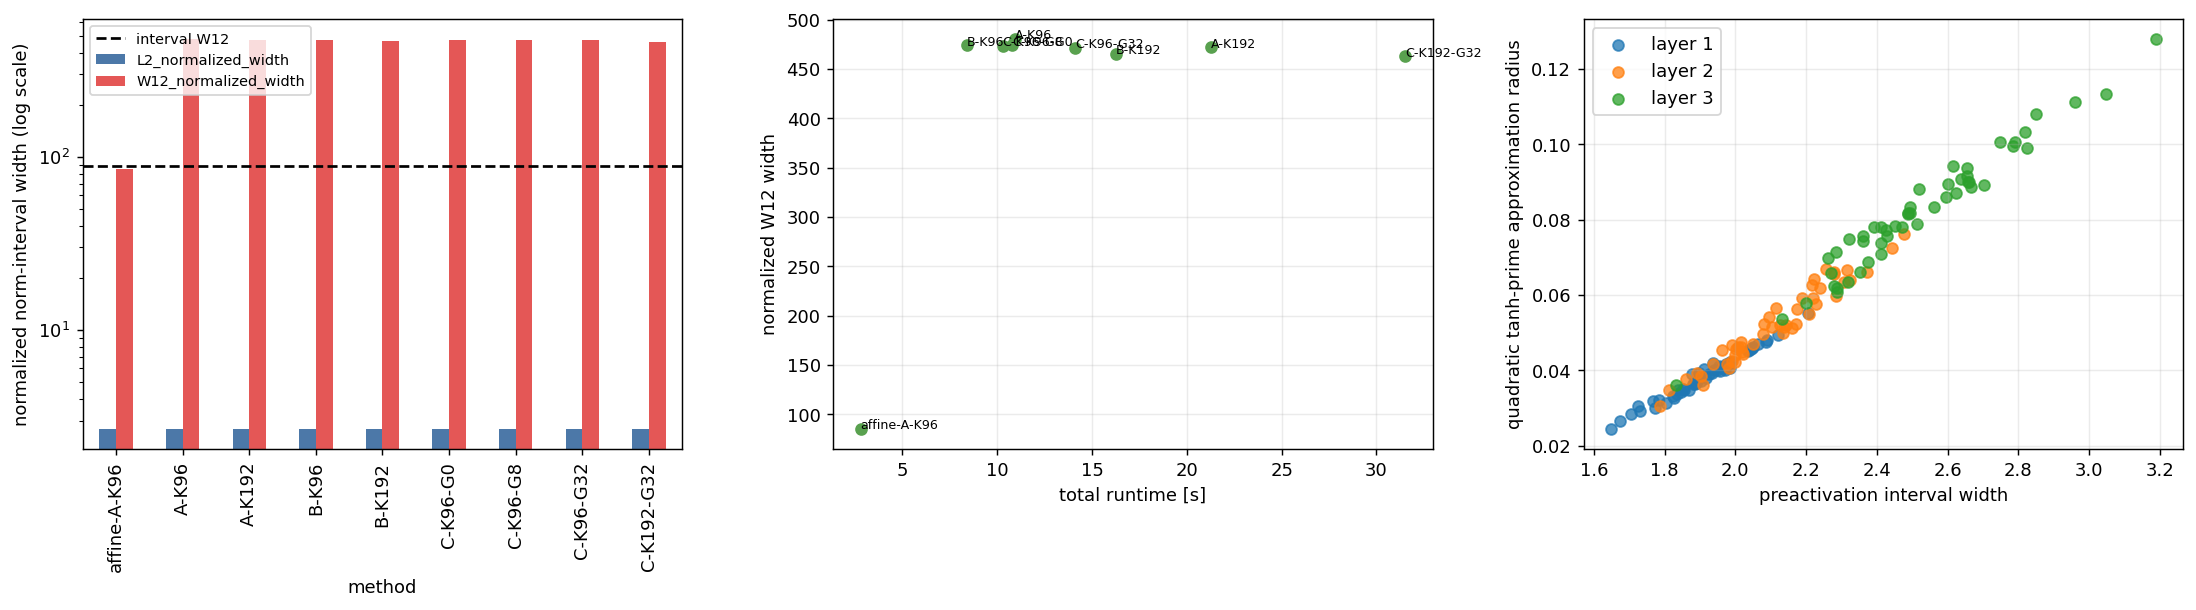

In [8]:
plot_methods = [name for name in benchmark_table.index if name != "interval"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

benchmark_table.loc[plot_methods, ["L2_normalized_width", "W12_normalized_width"]].plot.bar(
    ax=axes[0], logy=True, color=["#4C78A8", "#E45756"]
)
axes[0].axhline(benchmark_table.loc["interval", "W12_normalized_width"], color="black", linestyle="--", label="interval W12")
axes[0].set_ylabel("normalized norm-interval width (log scale)")
axes[0].legend(fontsize=8)

axes[1].scatter(
    benchmark_table.loc[plot_methods, "total_s"],
    benchmark_table.loc[plot_methods, "W12_normalized_width"],
    color="#59A14F",
)
for method in plot_methods:
    axes[1].annotate(method, (benchmark_table.loc[method, "total_s"], benchmark_table.loc[method, "W12_normalized_width"]), fontsize=7)
axes[1].set_xlabel("total runtime [s]")
axes[1].set_ylabel("normalized W12 width")
axes[1].grid(alpha=0.25)

representative = per_neuron_table.loc["B-K96"].reset_index()
for layer, group in representative.groupby("layer"):
    axes[2].scatter(group["preactivation_width"], group["tanh_prime_selected_rho"], label=f"layer {layer}", alpha=0.75)
axes[2].set_xlabel("preactivation interval width")
axes[2].set_ylabel("quadratic tanh-prime approximation radius")
axes[2].legend()
axes[2].grid(alpha=0.25)

fig.tight_layout()
plt.show()

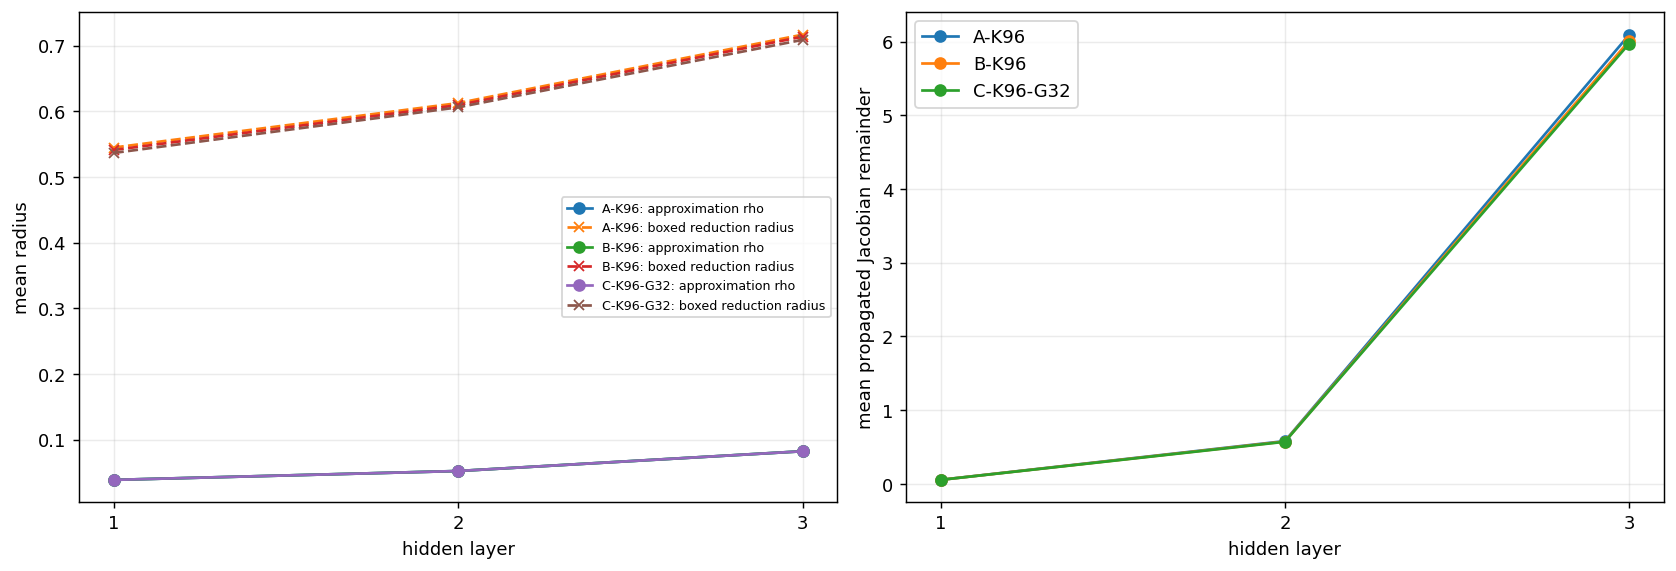

In [9]:
primary = layer_summary.loc[["A-K96", "B-K96", "C-K96-G32"]].reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for method, group in primary.groupby("method", sort=False):
    axes[0].plot(group["layer"], group["mean_tanh_prime_selected_rho"], marker="o", label=f"{method}: approximation rho")
    axes[0].plot(group["layer"], group["mean_quadratic_core_box_radius"], marker="x", linestyle="--", label=f"{method}: boxed reduction radius")
    axes[1].plot(group["layer"], group["mean_propagated_J_remainder"], marker="o", label=method)
axes[0].set_xlabel("hidden layer")
axes[0].set_ylabel("mean radius")
axes[0].set_xticks([1, 2, 3])
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.25)
axes[1].set_xlabel("hidden layer")
axes[1].set_ylabel("mean propagated Jacobian remainder")
axes[1].set_xticks([1, 2, 3])
axes[1].legend()
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Programmatic conclusion

The following cells rank the variants by final normalized $W^{1,2}$ width
and report how much B and C improve over A at the same retained support.

In [10]:
ranking = benchmark_table.sort_values("W12_normalized_width")[[
    "W12_normalized_lower", "W12_normalized_upper", "W12_normalized_width",
    "W12_relative_width", "L2_normalized_width", "J_mean_width", "total_s",
]]
display(ranking)

comparison = pd.DataFrame([
    {
        "comparison": "B-K96 versus A-K96",
        "W12_width_change_percent": 100 * (benchmark_table.loc["B-K96", "W12_normalized_width"] / benchmark_table.loc["A-K96", "W12_normalized_width"] - 1),
        "runtime_change_percent": 100 * (benchmark_table.loc["B-K96", "total_s"] / benchmark_table.loc["A-K96", "total_s"] - 1),
    },
    {
        "comparison": "C-K96-G32 versus B-K96",
        "W12_width_change_percent": 100 * (benchmark_table.loc["C-K96-G32", "W12_normalized_width"] / benchmark_table.loc["B-K96", "W12_normalized_width"] - 1),
        "runtime_change_percent": 100 * (benchmark_table.loc["C-K96-G32", "total_s"] / benchmark_table.loc["B-K96", "total_s"] - 1),
    },
    {
        "comparison": "B-K192 versus B-K96",
        "W12_width_change_percent": 100 * (benchmark_table.loc["B-K192", "W12_normalized_width"] / benchmark_table.loc["B-K96", "W12_normalized_width"] - 1),
        "runtime_change_percent": 100 * (benchmark_table.loc["B-K192", "total_s"] / benchmark_table.loc["B-K96", "total_s"] - 1),
    },
]).set_index("comparison")
display(comparison)

              W12_normalized_lower  W12_normalized_upper  \
method                                                     
affine-A-K96                   0.0             85.167723   
interval                       0.0             88.846805   
C-K192-G32                     0.0            462.682211   
B-K192                         0.0            465.534292   
C-K96-G32                      0.0            471.174670   
A-K192                         0.0            471.885901   
C-K96-G8                       0.0            473.419414   
B-K96                          0.0            474.166433   
C-K96-G0                       0.0            474.166433   
A-K96                          0.0            480.616605   

              W12_normalized_width  W12_relative_width  L2_normalized_width  \
method                                                                        
affine-A-K96             85.167723                 1.0             2.676831   
interval                 88.846805        

                        W12_width_change_percent  runtime_change_percent
comparison                                                              
B-K96 versus A-K96                     -1.342062              -23.081191
C-K96-G32 versus B-K96                 -0.630952               68.070199
B-K192 versus B-K96                    -1.820488               93.487296

## Interpretation of the executed 100D experiment

The three new reduction operators behave correctly and improve monotonically in the expected local sense, but they do **not** rescue the expanded quadratic one-jet on this network. Variant B is the correct cheap default: at Top-96 it lowers the normalized $W^{1,2}$ width from $480.6166$ (A) to $474.1664$, a $1.34\%$ improvement, and its parity test has negligible cost. C with 32 retained directions lowers this further to $471.1747$, but its runtime is about $63\%$ above B in this run. Increasing B's polynomial budget from 96 to 192 terms reaches $465.5343$, at roughly $2.49\times$ the runtime. The best tested quadratic configuration is C-K192-G32 at $462.6822$.

These gains are real, but the affine derivative control remains far tighter: affine-A-K96 has normalized $W^{1,2}$ width $85.1677$, and interval arithmetic has $88.8468$. The quadratic approximation radii themselves fall from layerwise affine means $(0.2751,0.3059,0.3594)$ to $(0.0385,0.0520,0.0821)$, yet the mean quadratic-core box radii under B-K96 are $(0.5412,0.6096,0.7139)$. Thus the new reductions recover only a small part of the dependence lost when the expanded square support is collapsed.

The small-network reference is important: there, B improves the mean Jacobian width from $0.07346$ to $0.06827$, and C with eight retained directions reaches $0.06458$, close to the unreduced value $0.06258$, with zero violations among the sampled Jacobians. The variants are therefore working as designed; the remaining failure on the 100D PINN is a scale/representation issue, not a failed quadratic certificate. A grouped or factored representation of $aZ^2+bZ+c$ is still the most promising next step.
